### Лабораторная работа №10: Генерация изображений в заданной художественной стилистике посредством диффузионной модели нейронной сети

### Установка зависимостей

In [ ]:
%pip install transformers diffusers translators

### Импорт библиотек и определение класса ImageGenerator
Здесь содержится основной класс, реализующий загрузку компонентов диффузионной модели (CLIP, VAE, U-Net) и процесс генерации изображения из шума

In [8]:
import torch                              # Для работы с нейронными сетями
import logging                            # Для логирования
from tqdm.auto import tqdm                # Полоска прогресса
from IPython.display import display       # Для вывода изображения в .ipynb файле
import os                                 # Для работы с папками
import translators as ts                  # Для перевода

# Библиотеки для работы с фотографиями
from PIL import Image
from torchvision import transforms as tfms

## Необходимые библиотеки для CLIP
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler

class ImageGenerator():
    def __init__(self) -> None:
        # Отключение предупреждений при логировании
        logging.disable(logging.WARNING)

        # Определение токенайзера и кодировщика
        self.tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14", torch_dtype=torch.float16)
        self.text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14", torch_dtype=torch.float16).to("cuda")

        # Определение VAE
        self.vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae", torch_dtype=torch.float16).to("cuda")

        # Создание необходимых объектов для последовательного зашумления изображения и установка шагов семплинга
        self.scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)
        self.scheduler.set_timesteps(50)

        ## Определение U-Net модели
        self.unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet", torch_dtype=torch.float16).to("cuda")

    def load_image(self, p) -> Image:
        '''Функция для загрузки изображения из определенного пути'''
        return Image.open(p).convert('RGB').resize((512,512))

    def pil_to_latents(self, image):
        '''Функция для преобразования изображения в латенты'''
        init_image = tfms.ToTensor()(image).unsqueeze(0) * 2.0 - 1.0
        init_image = init_image.to(device="cuda", dtype=torch.float16)
        init_latent_dist = self.vae.encode(init_image).latent_dist.sample() * 0.18215
        return init_latent_dist

    def latents_to_pil(self, latents):
        '''Функция для преобразования латентов в изображение'''
        latents = (1 / 0.18215) * latents
        with torch.no_grad():
            image = self.vae.decode(latents).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
        images = (image * 255).round().astype("uint8")
        pil_images = [Image.fromarray(image) for image in images]
        return pil_images

    def text_enc(self, prompts, maxlen=None):
        '''Функция, принимающая текстовую фразу и преобразующая ее в эмбеддинги'''
        if maxlen is None:
            maxlen = self.tokenizer.model_max_length
        inp = self.tokenizer(prompts, padding="max_length", max_length=maxlen, truncation=True, return_tensors="pt")
        return self.text_encoder(inp.input_ids.to("cuda"))[0].half()

    def prompt_2_img(self, prompts, g=7.5, seed=None, steps=70, dim=512, save_int=False):
        """Диффузионный процесс преобразования текстовой фразы в изображение"""
        # Определение размера блока
        bs = len(prompts)

        # Преобразование текстовой фразы в эмбеддинги
        text = self.text_enc(prompts)

        # Добавление безусловной фразы, помогает в процессе генерации
        uncond =  self.text_enc([""] * bs, text.shape[1])
        emb = torch.cat([uncond, text])

        # Установка сида
        if seed:
            torch.manual_seed(seed)

        # Начальный случайный шум
        latents = torch.randn((bs, self.unet.in_channels, dim//8, dim//8))

        # Установка количества шагов семплинга
        self.scheduler.set_timesteps(steps)

        # Добавление шума в латенты
        latents = latents.to("cuda").half() * self.scheduler.init_noise_sigma

        # Для каждого шага
        for i,ts in enumerate(tqdm(self.scheduler.timesteps)):
            # Необходимо масштабировать латентные значения i/p, чтобы они соответствовали дисперсии
            inp = self.scheduler.scale_model_input(torch.cat([latents] * 2), ts)

            # Прогнозирование остаточного шума с использованием U-Net
            with torch.no_grad(): u,t = self.unet(inp, ts, encoder_hidden_states=emb).sample.chunk(2)

            # Выполнение прогноза
            pred = u + g*(t-u)

            # Добавление условий в латенты
            latents = self.scheduler.step(pred, ts, latents).prev_sample

            # Сохранение изображений на каждом шаге
            if save_int:
                if not os.path.exists('./steps'):
                    os.mkdir('./steps')
                self.latents_to_pil(latents)[0].save(f'steps/{i:04}.jpeg')

        # Возвращаем латенты, которые представляют изображение размером 3x512x512
        return self.latents_to_pil(latents)

### Инициализация и генерация под предметную область
В этой ячейке происходит инициализация объекта ImageGenerator и передача ему списка заранее подготовленных фраз (промптов), описывающих предметную область варианта («Учет телефонных переговоров»). Программа автоматически переведет их на английский язык с помощью deepl и сгенерирует картинки

Инициализация моделей стабильной диффузии...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Модель успешно загружена!

Генерация изображения 1 по фразе: 'Офисный работник в деловом костюме совершает важный междугородний телефонный звонок, день, яркий свет, высокодетализированно'
Перевод фразы: 'An office worker in a business suit makes an important long-distance phone call, day, bright light, highly detailed'


/tmp/ipykernel_3582/4113966502.py:81: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latents = torch.randn((bs, self.unet.in_channels, dim//8, dim//8))


  0%|          | 0/50 [00:00<?, ?it/s]

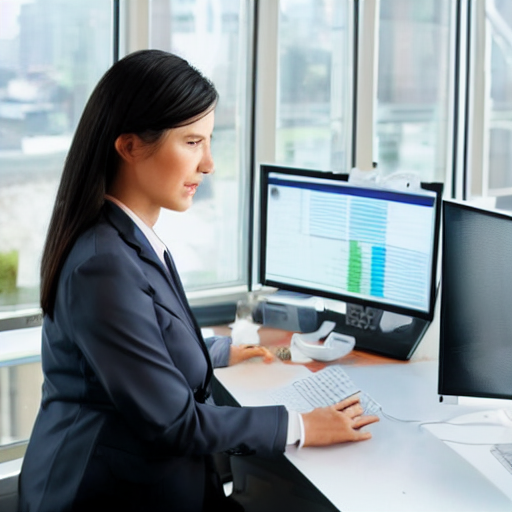


Генерация изображения 2 по фразе: 'Современная серверная комната телефонной компании, автоматическая фиксация звонков в базу данных, светящиеся кабели, ночь, киберпанк'
Перевод фразы: 'Modern server room of a telephone company, automatic recording of calls to a database, glowing cables, night, cyberpunk'


  0%|          | 0/50 [00:00<?, ?it/s]

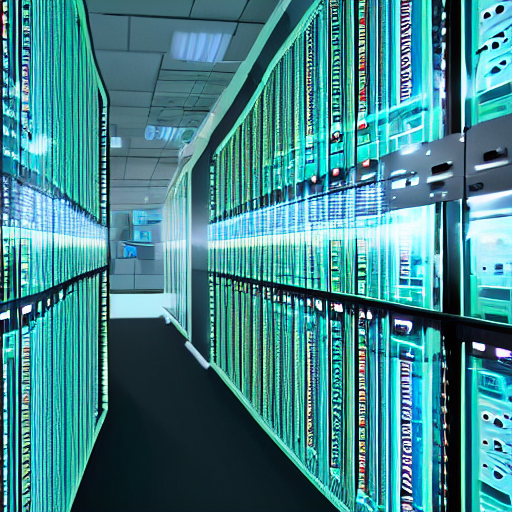


Генерация изображения 3 по фразе: 'Абстрактная визуализация телефонных линий связи, соединяющих разные города на карте, цифровое искусство, корпоративный стиль'
Перевод фразы: 'Abstract visualization of telephone communication lines connecting different cities on a map, digital art, corporate identity'


  0%|          | 0/50 [00:00<?, ?it/s]

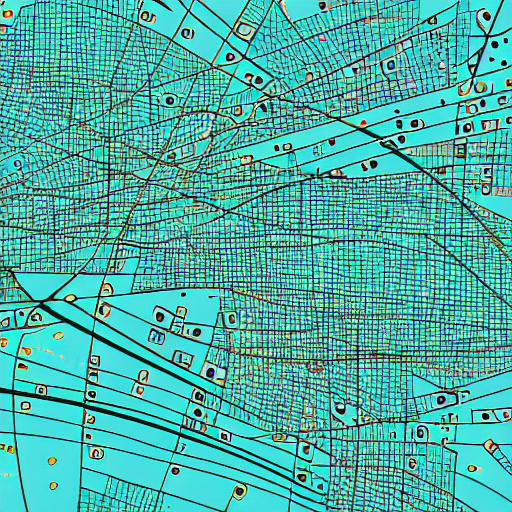

In [9]:
# Инициализируем генератор
print("Инициализация моделей стабильной диффузии...")
ig = ImageGenerator()
print("Модель успешно загружена!")

# Список промптов, описывающих предметную область "Учет телефонных переговоров"
prompts = [
    "Офисный работник в деловом костюме совершает важный междугородний телефонный звонок, день, яркий свет, высокодетализированно",
    "Современная серверная комната телефонной компании, автоматическая фиксация звонков в базу данных, светящиеся кабели, ночь, киберпанк",
    "Абстрактная визуализация телефонных линий связи, соединяющих разные города на карте, цифровое искусство, корпоративный стиль"
]

# Генерация изображений в цикле
for i, prompt in enumerate(prompts):
    print(f"\nГенерация изображения {i+1} по фразе: '{prompt}'")

    try:
        # Перевод на английский язык для лучшего понимания моделью CLIP
        engPrompt = ts.translate_text(prompt, "google", to_language="en")
        print(f"Перевод фразы: '{engPrompt}'")
    except Exception as e:
        print(f"Ошибка перевода, будет использован оригинальный текст: {e}")
        engPrompt = prompt

    # Запуск диффузионного процесса
    # Установили seed для воспроизводимости и steps=50 для баланса скорости/качества
    images = ig.prompt_2_img([engPrompt], save_int=False, seed=42, steps=50)

    # Вывод результата
    for img in images:
        display(img)